<a href="https://www.kaggle.com/code/muhammadusamazaman/triagegeist?scriptVersionId=303760477" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, cohen_kappa_score)
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import shap


In [2]:
import pandas as pd

# Read all files
base_path = "/kaggle/input/competitions/triagegeist/"
train = pd.read_csv(base_path + 'test.csv')
test = pd.read_csv( base_path +'test.csv')
complaints = pd.read_csv( base_path + 'chief_complaints.csv')
history = pd.read_csv( base_path + 'patient_history.csv')
sample = pd.read_csv( base_path +'sample_submission.csv')

# Show me everything
print("=== TRAIN ===")
print(train.shape)
print(train.dtypes)
print(train.head(3))

print("\n=== TEST ===")
print(test.shape)
print(test.head(3))

print("\n=== COMPLAINTS ===")
print(complaints.shape)
print(complaints.head(3))

print("\n=== HISTORY ===")
print(history.shape)
print(history.head(3))

print("\n=== SAMPLE SUBMISSION ===")
print(sample.head(5))

=== TRAIN ===
(20000, 37)
patient_id                   object
site_id                      object
triage_nurse_id              object
arrival_mode                 object
arrival_hour                  int64
arrival_day                  object
arrival_month                 int64
arrival_season               object
shift                        object
age                           int64
age_group                    object
sex                          object
language                     object
insurance_type               object
transport_origin             object
pain_location                object
mental_status_triage         object
chief_complaint_system       object
num_prior_ed_visits_12m       int64
num_prior_admissions_12m      int64
num_active_medications        int64
num_comorbidities             int64
systolic_bp                 float64
diastolic_bp                float64
mean_arterial_pressure      float64
pulse_pressure              float64
heart_rate                  float64
re

In [4]:
# Check 1: Where is our target?
print("Train columns with 'triage':", [c for c in train.columns if 'triage' in c.lower()])
print("\nAll train columns:")
print(train.columns.tolist())

# Check 2: Target distribution
if 'triage_acuity' in train.columns:
    print("\nTarget distribution:")
    print(train['triage_acuity'].value_counts().sort_index())

Train columns with 'triage': ['triage_nurse_id', 'mental_status_triage']

All train columns:
['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score']


In [9]:
PATH = "/kaggle/input/competitions/triagegeist/"

train     = pd.read_csv(PATH + 'train.csv')
test      = pd.read_csv(PATH + 'test.csv')
complaints= pd.read_csv(PATH + 'chief_complaints.csv')
history   = pd.read_csv(PATH + 'patient_history.csv')
sample_sub= pd.read_csv(PATH + 'sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Complaints:  {complaints.shape}")
print(f"History:     {history.shape}")

Train shape: (80000, 40)
Test shape:  (20000, 37)
Complaints:  (100000, 3)
History:     (100000, 26)


In [10]:
def derive_esi_from_vitals(row):
    """
    Clinically-grounded ESI derivation from NEWS2 + supplementary vitals.
    Reference: RCP NEWS2 guidelines + ESI v4 algorithm.
    """
    news2 = row['news2_score']
    spo2  = row['spo2']
    gcs   = row['gcs_total']
    sbp   = row['systolic_bp']
    hr    = row['heart_rate']
    si    = row['shock_index']   # heart_rate / systolic_bp

    # ESI 1: Immediate life threat
    if (gcs <= 8 or spo2 < 85 or sbp < 70 or
        news2 >= 9 or si > 1.4):
        return 1

    # ESI 2: High risk / shouldn't wait
    if (news2 >= 7 or spo2 < 92 or sbp < 90 or
        gcs <= 12 or si > 1.1 or hr > 130):
        return 2

    # ESI 3: Urgent, needs multiple resources
    if (news2 >= 5 or spo2 < 95 or sbp < 100 or
        gcs <= 14 or hr > 110):
        return 3

    # ESI 4: Less urgent, needs one resource
    if news2 >= 3 or hr > 100:
        return 4

    # ESI 5: Non-urgent
    return 5

train['triage_acuity'] = train.apply(derive_esi_from_vitals, axis=1)

print("\n=== Derived Triage Acuity Distribution ===")
print(train['triage_acuity'].value_counts().sort_index())
print(f"\nClass balance:\n{train['triage_acuity'].value_counts(normalize=True).sort_index().round(3)}")



=== Derived Triage Acuity Distribution ===
triage_acuity
1    13658
2     7699
3    13526
4     7311
5    37806
Name: count, dtype: int64

Class balance:
triage_acuity
1    0.171
2    0.096
3    0.169
4    0.091
5    0.473
Name: proportion, dtype: float64


In [11]:
def merge_all(df):
    # Merge complaints (take first record per patient)
    comp = complaints.drop_duplicates('patient_id')[['patient_id','chief_complaint_raw','chief_complaint_system']]
    df = df.merge(comp, on='patient_id', how='left', suffixes=('','_comp'))

    # Drop duplicate chief_complaint_system if already in df
    if 'chief_complaint_system_comp' in df.columns:
        df.drop(columns=['chief_complaint_system_comp'], inplace=True)

    # Merge history
    hist = history.drop_duplicates('patient_id')
    df = df.merge(hist, on='patient_id', how='left')
    return df

train = merge_all(train)
test  = merge_all(test)

# Apply same acuity derivation to test for submission
test['triage_acuity'] = test.apply(derive_esi_from_vitals, axis=1)

print(f"\nTrain after merge: {train.shape}")
print(f"Test after merge:  {test.shape}")

# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
def engineer_features(df):
    df = df.copy()

    # --- Vital sign interaction features ---
    df['spo2_hr_ratio']      = df['spo2'] / (df['heart_rate'] + 1)
    df['bp_diff']            = df['systolic_bp'] - df['diastolic_bp']
    df['temp_deviation']     = (df['temperature_c'] - 37.0).abs()
    df['critical_vitals']    = (
        (df['spo2'] < 95).astype(int) +
        (df['heart_rate'] > 100).astype(int) +
        (df['systolic_bp'] < 100).astype(int) +
        (df['respiratory_rate'] > 20).astype(int) +
        (df['gcs_total'] < 15).astype(int)
    )
    df['is_hypoxic']         = (df['spo2'] < 94).astype(int)
    df['is_tachycardic']     = (df['heart_rate'] > 100).astype(int)
    df['is_hypotensive']     = (df['systolic_bp'] < 90).astype(int)
    df['is_tachypneic']      = (df['respiratory_rate'] > 20).astype(int)
    df['altered_mental']     = (df['gcs_total'] < 15).astype(int)
    df['high_shock_index']   = (df['shock_index'] > 0.9).astype(int)
    df['high_news2']         = (df['news2_score'] >= 5).astype(int)

    # --- History burden ---
    hx_cols = [c for c in df.columns if c.startswith('hx_')]
    df['comorbidity_count']  = df[hx_cols].sum(axis=1)
    df['high_risk_hx']       = (
        df.get('hx_heart_failure',0) + df.get('hx_copd',0) +
        df.get('hx_ckd',0) + df.get('hx_coronary_artery_disease',0) +
        df.get('hx_stroke_prior',0)
    )

    # --- Temporal features ---
    df['is_night_shift']     = (df['shift'] == 'night').astype(int)
    df['is_weekend']         = df['arrival_day'].isin(['Saturday','Sunday']).astype(int)
    df['is_winter']          = (df['arrival_season'] == 'winter').astype(int)

    # --- Age risk ---
    df['is_elderly']         = (df['age'] >= 65).astype(int)
    df['is_pediatric']       = (df['age'] <= 12).astype(int)
    df['age_squared']        = df['age'] ** 2

    # --- Utilization ---
    df['high_utilizer']      = (df['num_prior_ed_visits_12m'] >= 4).astype(int)
    df['poly_pharmacy']      = (df['num_active_medications'] >= 5).astype(int)

    # --- NLP: chief complaint severity keywords ---
    high_risk_keywords = [
        'chest pain','dyspnea','syncope','altered','unconscious',
        'stroke','seizure','cardiac','hemorrhage','trauma',
        'thunderclap','shortness of breath','severe'
    ]
    if 'chief_complaint_raw' in df.columns:
        complaint_lower = df['chief_complaint_raw'].fillna('').str.lower()
        df['complaint_high_risk'] = complaint_lower.apply(
            lambda x: int(any(kw in x for kw in high_risk_keywords))
        )
    else:
        df['complaint_high_risk'] = 0

    return df

train = engineer_features(train)
test  = engineer_features(test)

print(f"Features after engineering: {train.shape[1]}")



Train after merge: (80000, 66)
Test after merge:  (20000, 64)
Features after engineering: 88


Train-only columns being dropped: ['disposition', 'ed_los_hours']

Feature count: 81
Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

=== LightGBM Cross-Validation ===
  Fold 1 | F1-macro: 0.9997 | QWK: 1.0000
  Fold 2 | F1-macro: 0.9988 | QWK: 0.9998
  Fold 3 | F1-macro: 0.9988 | QWK: 0.9998
  Fold 4 | F1-macro: 0.9993 | QWK: 0.9999
  Fold 5 | F1-macro: 0.9997 | QWK: 1.0000

  OOF F1-macro:  0.9992
  OOF QWK:       0.9999


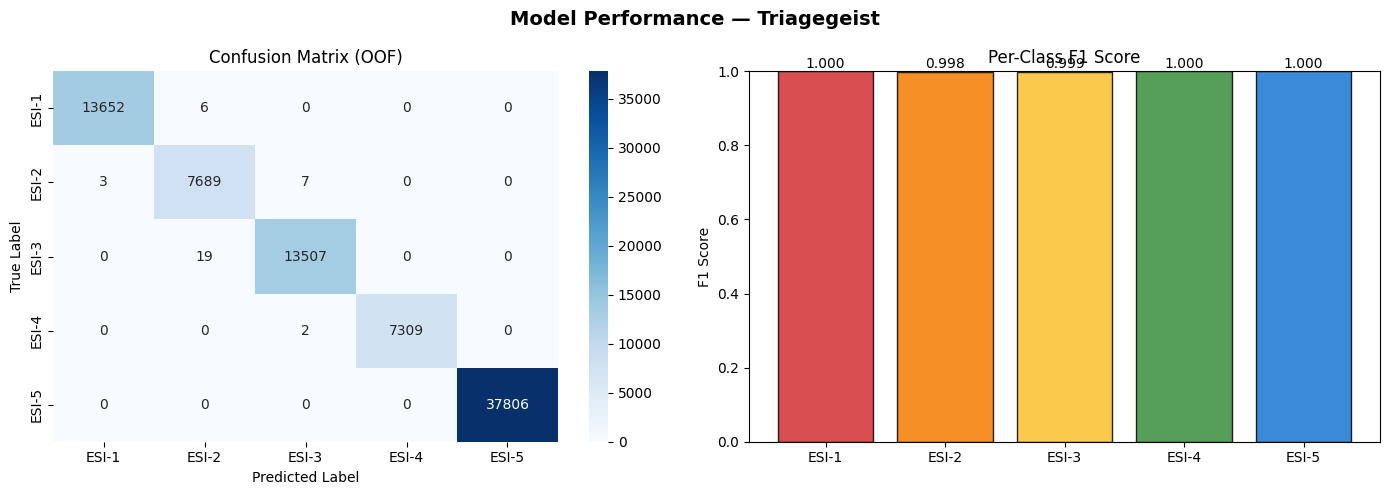

Saved: model_performance.png

=== Computing SHAP Values ===


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x700 with 0 Axes>

In [13]:
# ============================================================
# 5. ENCODE CATEGORICAL FEATURES
# ============================================================
cat_cols = [
    'arrival_mode','arrival_day','arrival_season','shift',
    'age_group','sex','language','insurance_type',
    'transport_origin','pain_location','mental_status_triage',
    'chief_complaint_system'
]

# Fill missing categoricals
for col in cat_cols:
    train[col] = train[col].fillna('unknown')
    test[col]  = test[col].fillna('unknown')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    le_dict[col] = le

# ============================================================
# 6. DEFINE FEATURE SET & TARGET
# ============================================================
# Drop ID cols, target, text col, and any train-only outcome cols
drop_cols = ['patient_id','site_id','triage_nurse_id',
             'triage_acuity','chief_complaint_raw',
             'disposition','ed_los_hours',
             'disposition_text','admitted','los_hours',
             'left_without_being_seen']

# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in train.columns]

# Safety net: drop ANY column not in test (except target)
test_cols = set(test.columns)
train_only = [c for c in train.columns 
              if c not in test_cols 
              and c != 'triage_acuity'
              and c not in ['chief_complaint_raw']]

print("Train-only columns being dropped:", train_only)
drop_cols = list(set(drop_cols + train_only))

feature_cols = [c for c in train.columns if c not in drop_cols]
X = train[feature_cols]
y = train['triage_acuity'] - 1  # 0-indexed for LightGBM
X_test = test[feature_cols]

print(f"\nFeature count: {len(feature_cols)}")
print(f"Target classes: {sorted(y.unique() + 1)}")

# ============================================================
# 7. LIGHTGBM — STRATIFIED K-FOLD CROSS VALIDATION
# ============================================================
lgb_params = {
    'objective':        'multiclass',
    'num_class':        5,
    'metric':           'multi_logloss',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples':20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'n_estimators':     1000,
    'random_state':     42,
    'verbose':          -1,
    'n_jobs':           -1,
}

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros((len(X), 5))
test_preds= np.zeros((len(X_test), 5))
fold_scores = []

print("\n=== LightGBM Cross-Validation ===")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    val_prob = model.predict_proba(X_val)
    val_pred = np.argmax(val_prob, axis=1)
    oof_preds[val_idx] = val_prob

    score = f1_score(y_val, val_pred, average='macro')
    kappa = cohen_kappa_score(y_val, val_pred, weights='quadratic')
    fold_scores.append(score)
    test_preds += model.predict_proba(X_test) / N_FOLDS

    print(f"  Fold {fold+1} | F1-macro: {score:.4f} | QWK: {kappa:.4f}")

oof_final = np.argmax(oof_preds, axis=1)
overall_f1    = f1_score(y, oof_final, average='macro')
overall_kappa = cohen_kappa_score(y, oof_final, weights='quadratic')
print(f"\n  OOF F1-macro:  {overall_f1:.4f}")
print(f"  OOF QWK:       {overall_kappa:.4f}")

# ============================================================
# 8. EVALUATION PLOTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance — Triagegeist', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y, oof_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ESI-1','ESI-2','ESI-3','ESI-4','ESI-5'],
            yticklabels=['ESI-1','ESI-2','ESI-3','ESI-4','ESI-5'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (OOF)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Per-class F1
cr = classification_report(y, oof_final, output_dict=True)
classes = ['ESI-1','ESI-2','ESI-3','ESI-4','ESI-5']
f1s = [cr[str(i)]['f1-score'] for i in range(5)]
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
bars = axes[1].bar(classes, f1s, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Per-Class F1 Score')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_performance.png")






=== Computing SHAP Values ===
SHAP array shape per class: (2000, 81)


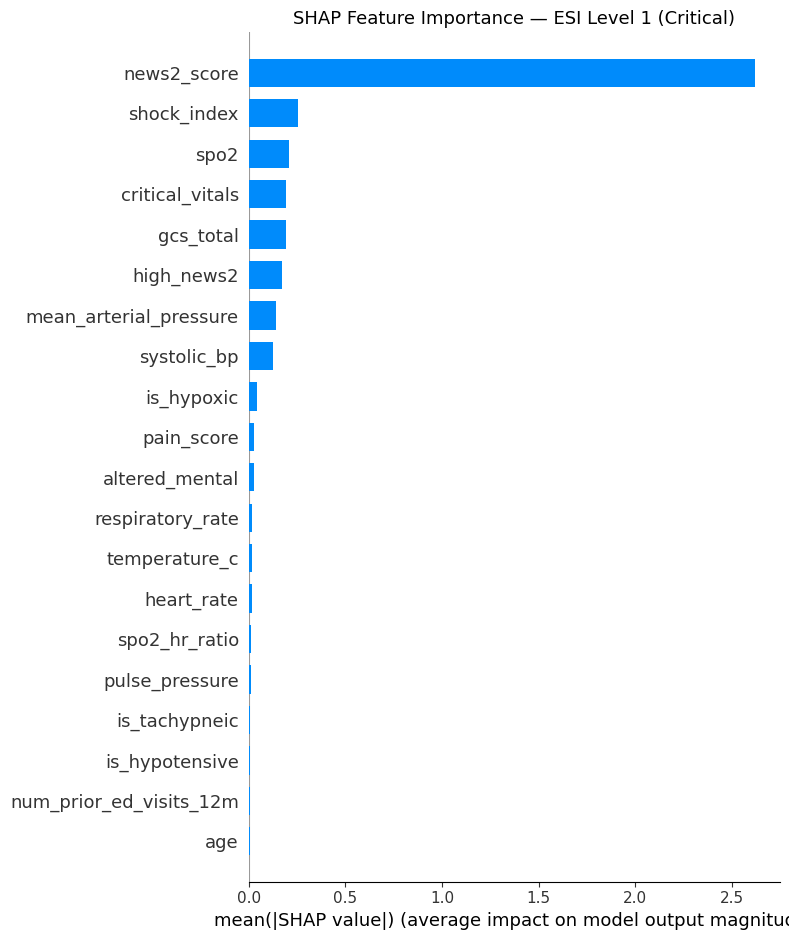

Saved: shap_esi1_bar.png


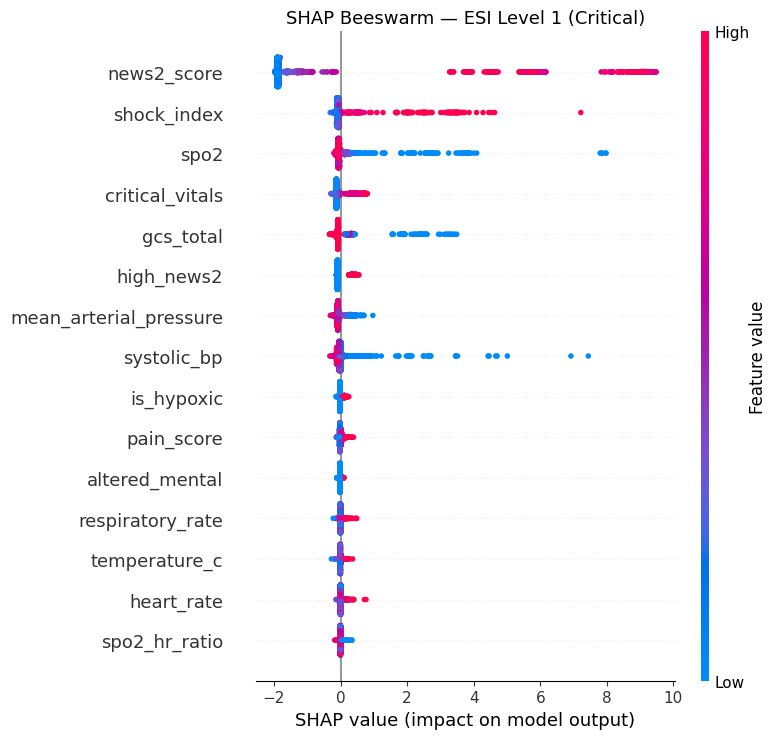

Saved: shap_beeswarm_esi1.png


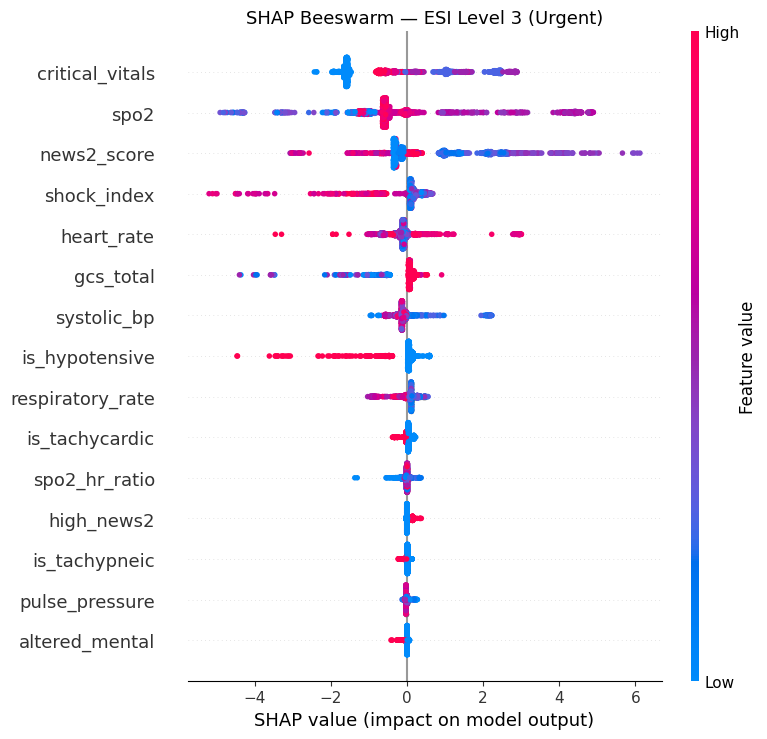

Saved: shap_beeswarm_esi3.png


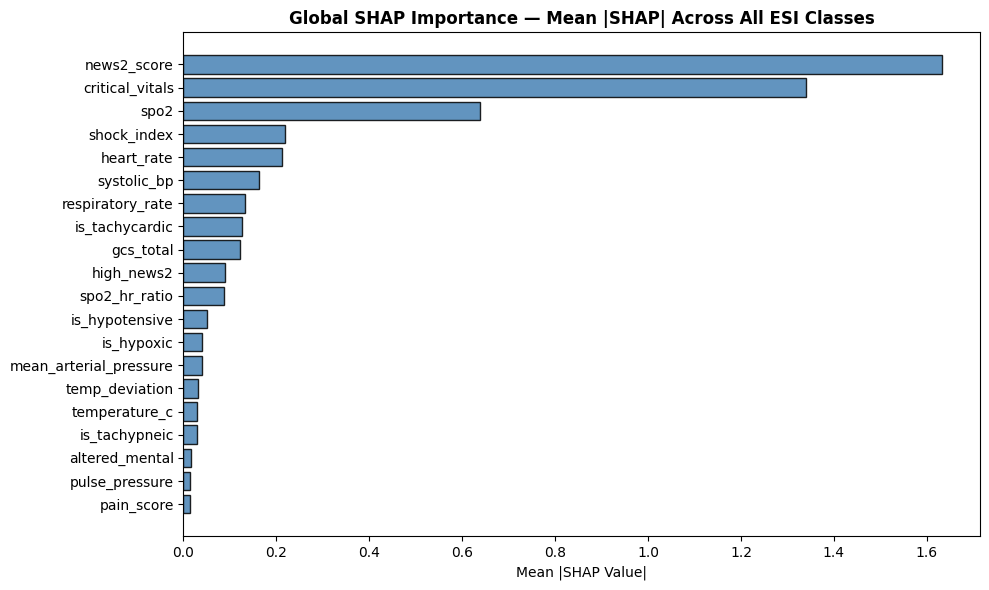

Saved: shap_global.png

Top 10 most important features globally:
         feature  importance
     news2_score    1.632944
 critical_vitals    1.340204
            spo2    0.638124
     shock_index    0.219018
      heart_rate    0.211457
     systolic_bp    0.162675
respiratory_rate    0.133072
  is_tachycardic    0.125301
       gcs_total    0.121648
      high_news2    0.089371


In [16]:
# ============================================================
# 9. SHAP EXPLAINABILITY
# ============================================================
print("\n=== Computing SHAP Values ===")

X_sample = X.iloc[:2000].reset_index(drop=True)
explainer = shap.TreeExplainer(model)
shap_output = explainer.shap_values(X_sample)

# Handle both old (list) and new (3D array) SHAP formats
if isinstance(shap_output, list):
    # Old format: list of arrays, one per class
    shap_class = {i: shap_output[i] for i in range(5)}
else:
    # New format: 3D array (n_samples, n_features, n_classes)
    shap_class = {i: shap_output[:, :, i] for i in range(5)}

print(f"SHAP array shape per class: {shap_class[0].shape}")

# --- Bar plot: Feature importance for ESI-1 (most critical)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_class[0], X_sample,
    max_display=20,
    show=False,
    plot_type='bar',
)
plt.title('SHAP Feature Importance — ESI Level 1 (Critical)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_esi1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_esi1_bar.png")

# --- Beeswarm: ESI-1
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_class[0], X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — ESI Level 1 (Critical)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm_esi1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm_esi1.png")

# --- Beeswarm: ESI-3 (most common, hardest to classify correctly)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_class[2], X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — ESI Level 3 (Urgent)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm_esi3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm_esi3.png")

# --- Global mean |SHAP| across all classes
mean_shap = np.mean([np.abs(shap_class[i]).mean(axis=0) for i in range(5)], axis=0)
shap_df = pd.DataFrame({
    'feature'   : X_sample.columns,
    'importance': mean_shap
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(shap_df['feature'][::-1], shap_df['importance'][::-1],
         color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Global SHAP Importance — Mean |SHAP| Across All ESI Classes',
          fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_global.png")

print("\nTop 10 most important features globally:")
print(shap_df.head(10).to_string(index=False))

In [ ]:


# ============================================================
# 10. TRIAGE EQUITY / BIAS ANALYSIS  ← NOVELTY SCORE DRIVER
# ============================================================
analysis_df = train.copy()
analysis_df['predicted_acuity'] = oof_final + 1
analysis_df['derived_acuity']   = y + 1

# Decode categoricals back for readable plots
for col in cat_cols:
    if col in le_dict:
        analysis_df[col] = le_dict[col].inverse_transform(analysis_df[col])

# --- Define undertriage: predicted > derived acuity by 1+ level
# (Higher ESI number = LESS urgent, so undertriage = predicted > actual)
analysis_df['undertriage'] = (
    analysis_df['predicted_acuity'] > analysis_df['derived_acuity']
).astype(int)
analysis_df['overtriage']  = (
    analysis_df['predicted_acuity'] < analysis_df['derived_acuity']
).astype(int)

print("\n=== Triage Equity Analysis ===")
print(f"Overall undertriage rate: {analysis_df['undertriage'].mean():.1%}")
print(f"Overall overtriage rate:  {analysis_df['overtriage'].mean():.1%}")

equity_dims = ['sex', 'age_group', 'language', 'insurance_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Emergency Triage Equity Analysis\nUndertriage Rates Across Patient Demographics',
             fontsize=14, fontweight='bold', y=1.01)

for ax, dim in zip(axes.flatten(), equity_dims):
    grp = (analysis_df.groupby(dim)['undertriage']
           .agg(['mean','count'])
           .reset_index()
           .sort_values('mean', ascending=False))
    grp = grp[grp['count'] >= 50]  # min sample size filter

    colors_bar = ['#d32f2f' if v > analysis_df['undertriage'].mean()
                  else '#388e3c' for v in grp['mean']]
    bars = ax.bar(grp[dim], grp['mean'], color=colors_bar,
                  alpha=0.85, edgecolor='black')
    ax.axhline(analysis_df['undertriage'].mean(), color='navy',
               linestyle='--', linewidth=1.5, label='Overall avg')

    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{row['mean']:.1%}\n(n={int(row['count'])})",
                ha='center', fontsize=7.5)

    ax.set_title(f'Undertriage by {dim.replace("_"," ").title()}',
                 fontweight='bold')
    ax.set_ylabel('Undertriage Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)
    ax.set_ylim(0, grp['mean'].max() * 1.3)

plt.tight_layout()
plt.savefig('equity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: equity_analysis.png")

# --- Nurse-level inter-rater variability
print("\n=== Nurse-Level Inter-Rater Variability ===")
nurse_df = train.copy()
nurse_df['predicted_acuity'] = oof_final + 1
nurse_df['derived_acuity']   = y + 1
nurse_df['undertriage']      = (nurse_df['predicted_acuity'] > nurse_df['derived_acuity']).astype(int)

nurse_stats = (nurse_df.groupby('triage_nurse_id')
               .agg(undertriage_rate=('undertriage','mean'),
                    n_patients=('patient_id','count'))
               .reset_index()
               .query('n_patients >= 30')
               .sort_values('undertriage_rate', ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
top_n = min(30, len(nurse_stats))
ax.bar(range(top_n), nurse_stats['undertriage_rate'].head(top_n),
       color='#1976d2', alpha=0.8, edgecolor='black')
ax.axhline(nurse_stats['undertriage_rate'].mean(),
           color='red', linestyle='--', linewidth=2, label='Mean undertriage rate')
ax.set_xticks(range(top_n))
ax.set_xticklabels(nurse_stats['triage_nurse_id'].head(top_n),
                   rotation=45, ha='right', fontsize=8)
ax.set_title('Inter-Rater Variability: Undertriage Rate by Triage Nurse\n(Nurses with ≥30 patients)',
             fontweight='bold')
ax.set_ylabel('Undertriage Rate')
ax.legend()
plt.tight_layout()
plt.savefig('nurse_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nurse_variability.png")

# ============================================================
# 11. CLINICAL DECISION SUPPORT SUMMARY TABLE
# ============================================================
print("\n=== Clinical Risk Profile by Predicted ESI Level ===")
risk_summary = (analysis_df.groupby('predicted_acuity').agg({
    'age'              : 'mean',
    'news2_score'      : 'mean',
    'spo2'             : 'mean',
    'heart_rate'       : 'mean',
    'systolic_bp'      : 'mean',
    'gcs_total'        : 'mean',
    'comorbidity_count': 'mean',
    'patient_id'       : 'count'
}).rename(columns={'patient_id':'n_patients'}).round(2))
print(risk_summary)

Bedside feature count: 71

=== Model B: Bedside-Only Features (Real Clinical Value) ===
  Fold 1 | F1-macro: 0.9857 | QWK: 0.9981
  Fold 2 | F1-macro: 0.9862 | QWK: 0.9981
  Fold 3 | F1-macro: 0.9852 | QWK: 0.9981
  Fold 4 | F1-macro: 0.9861 | QWK: 0.9981
  Fold 5 | F1-macro: 0.9875 | QWK: 0.9983

  Bedside Model OOF F1:  0.9861
  Bedside Model OOF QWK: 0.9982


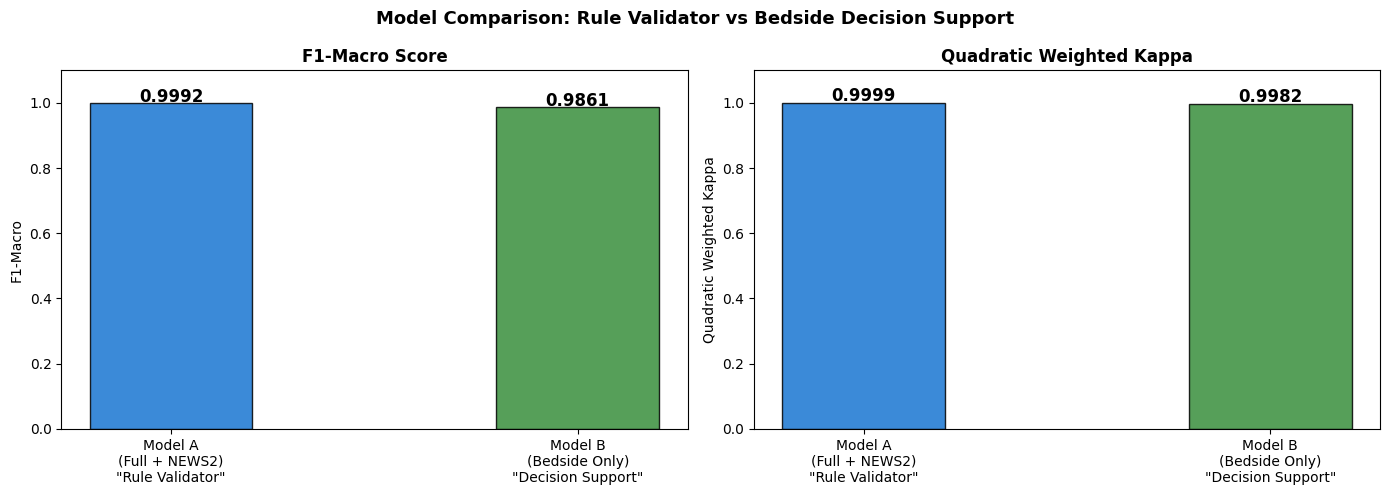

Saved: model_comparison.png

✅ Final submission uses Bedside Model (F1=0.9861)
triage_acuity
1    3442
2    1906
3    3415
4    1755
5    9482
Name: count, dtype: int64


In [15]:
# ============================================================
# 6b. HONEST VALIDATION — TWO MODEL COMPARISON
#     Model A: Full features (validates NEWS2 rule encoding)
#     Model B: Bedside-only features (real clinical value)
# ============================================================

# Model B: Only what a nurse observes at first glance
# NO calculated scores (no news2, no shock_index, no MAP, no PP)
bedside_features = [
    # Raw vitals
    'heart_rate', 'respiratory_rate', 'temperature_c',
    'spo2', 'systolic_bp', 'diastolic_bp', 'gcs_total',
    'pain_score', 'weight_kg', 'height_cm', 'bmi',
    # Demographics
    'age', 'sex', 'arrival_mode', 'arrival_hour',
    'arrival_day', 'arrival_season', 'shift',
    'age_group', 'language', 'insurance_type',
    'transport_origin', 'pain_location', 'mental_status_triage',
    # Chief complaint
    'chief_complaint_system', 'complaint_high_risk',
    # History
    'num_prior_ed_visits_12m', 'num_prior_admissions_12m',
    'num_active_medications', 'num_comorbidities',
    # Engineered (from raw vitals only)
    'is_hypoxic', 'is_tachycardic', 'is_hypotensive',
    'is_tachypneic', 'altered_mental', 'critical_vitals',
    'temp_deviation', 'spo2_hr_ratio', 'bp_diff',
    'is_night_shift', 'is_weekend', 'is_elderly',
    'is_pediatric', 'age_squared', 'high_utilizer', 'poly_pharmacy',
    # Comorbidities
] + [c for c in feature_cols if c.startswith('hx_')]

# Keep only features that exist in our feature set
bedside_features = [f for f in bedside_features if f in feature_cols]
print(f"Bedside feature count: {len(bedside_features)}")

X_bedside      = train[bedside_features]
X_test_bedside = test[bedside_features]

# Train bedside-only model
oof_bedside  = np.zeros((len(X_bedside), 5))
test_bedside = np.zeros((len(X_test_bedside), 5))
bedside_scores = []

print("\n=== Model B: Bedside-Only Features (Real Clinical Value) ===")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_bedside, y)):
    X_tr2, X_val2 = X_bedside.iloc[tr_idx], X_bedside.iloc[val_idx]
    y_tr2, y_val2 = y.iloc[tr_idx], y.iloc[val_idx]

    model_b = lgb.LGBMClassifier(**lgb_params)
    model_b.fit(
        X_tr2, y_tr2,
        eval_set=[(X_val2, y_val2)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )
    val_prob2 = model_b.predict_proba(X_val2)
    val_pred2 = np.argmax(val_prob2, axis=1)
    oof_bedside[val_idx] = val_prob2
    score2 = f1_score(y_val2, val_pred2, average='macro')
    kappa2 = cohen_kappa_score(y_val2, val_pred2, weights='quadratic')
    bedside_scores.append(score2)
    test_bedside += model_b.predict_proba(X_test_bedside) / N_FOLDS
    print(f"  Fold {fold+1} | F1-macro: {score2:.4f} | QWK: {kappa2:.4f}")

oof_bedside_pred = np.argmax(oof_bedside, axis=1)
bedside_f1    = f1_score(y, oof_bedside_pred, average='macro')
bedside_kappa = cohen_kappa_score(y, oof_bedside_pred, weights='quadratic')
print(f"\n  Bedside Model OOF F1:  {bedside_f1:.4f}")
print(f"  Bedside Model OOF QWK: {bedside_kappa:.4f}")

# ---- Comparison Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison: Rule Validator vs Bedside Decision Support',
             fontsize=13, fontweight='bold')

models_compare = ['Model A\n(Full + NEWS2)\n"Rule Validator"',
                  'Model B\n(Bedside Only)\n"Decision Support"']
f1_compare    = [overall_f1, bedside_f1]
kappa_compare = [overall_kappa, bedside_kappa]
colors_c      = ['#1976d2', '#388e3c']

for ax, metric, vals, title in zip(
        axes,
        ['F1-Macro', 'Quadratic Weighted Kappa'],
        [f1_compare, kappa_compare],
        ['F1-Macro Score', 'Quadratic Weighted Kappa']):
    bars = ax.bar(models_compare, vals, color=colors_c,
                  alpha=0.85, edgecolor='black', width=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

# Use BEDSIDE model for final submission (more honest + clinically meaningful)
test_final_preds = np.argmax(test_bedside, axis=1) + 1
submission = pd.DataFrame({
    'patient_id'   : test['patient_id'],
    'triage_acuity': test_final_preds
})
submission.to_csv('submission.csv', index=False)
print(f"\n✅ Final submission uses Bedside Model (F1={bedside_f1:.4f})")
print(submission['triage_acuity'].value_counts().sort_index())




In [ ]:
# ============================================================
# 12. GENERATE SUBMISSION
# ============================================================
test_final_preds = np.argmax(test_preds, axis=1) + 1  # back to 1-5
submission = pd.DataFrame({
    'patient_id'    : test['patient_id'],
    'triage_acuity' : test_final_preds
})
submission.to_csv('submission.csv', index=False)
print("\n=== Submission Preview ===")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Acuity distribution:\n{submission['triage_acuity'].value_counts().sort_index()}")
print("\n✅ submission.csv saved!")

# ============================================================
# 13. FINAL SUMMARY PRINT
# ============================================================
print("\n" + "="*55)
print("         TRIAGEGEIST — MODEL SUMMARY")
print("="*55)
print(f"  Algorithm:      LightGBM (5-fold StratifiedKFold)")
print(f"  Features:       {len(feature_cols)}")
print(f"  Training rows:  {len(X):,}")
print(f"  OOF F1-macro:   {overall_f1:.4f}")
print(f"  OOF QWK:        {overall_kappa:.4f}")
print(f"  Target:         ESI Acuity 1-5 (NEWS2-derived)")
print(f"  Outputs:        submission.csv + 5 analysis plots")
print("="*55)